[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Liquid4All/cookbook/blob/main/finetuning/notebooks/grpo_with_trl_ifstruct.ipynb)

# Fine-tune LFM2.5-350M for Structured Output Compliance with TRL GRPO

In this notebook, we will walk through how to fine-tune an [LFM2.5-350M model](https://huggingface.co/LiquidAI/LFM2.5-350M) with GRPO using the [TRL library](https://huggingface.co/docs/trl/en/index).

The goal of this notebook is to train **schema compliance only**, as described in the [IFStruct blog post](https://www.liquid.ai/blog/ifstruct-v1.0). The rewards do not judge whether extracted values are semantically correct. Instead, they only judge whether the generated response follows the requested JSON format and JSON Schema.

This notebook covers the training pipeline discussed in the accompanying blog post ["accompanying blog post"](https://huggingface.co/blog/LiquidAI/grpo-with-trl-ifstruct).

**Note, this is not the training pipeline used to train the RL model described in the [IFStruct blog post](https://www.liquid.ai/blog/ifstruct-v1.0). The goal of this notebook is not to recreate the IFStruct benchmark score but to show how fine-tuning can improve eval scores.**

## Prerequisites

**Hardware and runtime.** This notebook can be run on a free-tier Colab or Kaggle notebook. Expect about 4 hours for a 100-step training run on a T4 (or 1.5 hours on A100).

**Hugging Face token (optional)** If you want to enable authenticated Hub downloads or push the trained model to the Hugging Face Hub, store an `HF_TOKEN` in your platform's secrets manager or the environment variables.

## Install required packages

In [1]:
%pip install -q "trl==1.7.1" "transformers==5.13.0" "peft==0.19.1" "torchao>=0.16.0" datasets accelerate jsonschema matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.4/842.4 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 151.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.8 MB/s eta 0:00:00


## Imports and Configuration


In [2]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True" # Let PyTorch grow memory segments to reduce fragmentation and OOMs.

In [ ]:
import torch
import transformers

# Uncomment to set HF_TOKEN in Kaggle
# from kaggle_secrets import UserSecretsClient
# os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

SEED = 42
transformers.set_seed(SEED)  # seeds python, numpy, and torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

## Load Dataset

For this tutorial, we will use the open [`nvidia/Nemotron-RL-instruction_following-structured_outputs`](https://huggingface.co/datasets/nvidia/Nemotron-RL-instruction_following-structured_outputs) dataset, which tests the ability of a model to follow output JSON formatting instructions under schema constraints.

In [4]:
from datasets import load_dataset

DATASET_ID = "nvidia/Nemotron-RL-instruction_following-structured_outputs"
TRAIN_SAMPLES = 1000  # filtered down to about 500 during data cleaning

train_ds = load_dataset(DATASET_ID, split=f"train[:{TRAIN_SAMPLES}]")

train_ds

README.md:   0%|          | 0.00/2.66k [00:00<?, ?B/s]

structured_outputs_251027_nano_v3_sdg_js(…):   0%|          | 0.00/91.0M [00:00<?, ?B/s]

(…)utputs_251027_nano_v3_sdg_json_val.jsonl:   0%|          | 0.00/4.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9437 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/512 [00:00<?, ? examples/s]

Dataset({
    features: ['responses_create_params', 'schema_str', 'schema_type', 'schema_fields_count'],
    num_rows: 1000
})

## Data Preparation

[`GRPOTrainer`](https://huggingface.co/docs/trl/en/grpo_trainer) expects a `prompt` column in the format `{"role":  ..., "content":...}`. The `responses_create_params` column already contains this information under the `"input"` field. That's why we will replace the column `responses_create_params` with `row["responses_create_params"]["input"]` and rename it to `prompt`.

Reward functions receive the other columns (`schema_str`, `schema_type`, and `schema_fields_count`) through `**kwargs`.

We will apply the following **data cleaning** steps:

- `prompt_fits`: Prompts longer than 6,000 characters (~1,600 tokens) are dropped to reduce step time on free-tier GPUs.
- `schema_is_valid`: Rows with unusable JSON schema (e.g., not parseable or not valid) are dropped as well.

We will also apply a **data augmentation step**, `augment`, to close two gaps between the training data and the IFStruct benchmark: Nemotron prompts ask for a single top-level JSON object as raw JSON, so a model trained on them never practices fenced output or bare top-level arrays. `augment` therefore rewrites a percentage of the training prompts:

- 40% get `"Return the output inside a fenced code block."` appended, so the model learns to follow the format instruction rather than a fixed habit.
- A disjoint 20% become top-level-array tasks: the schema is wrapped in `{"type": "array", "items": ..., "minItems": n, "maxItems": n}` and the prompt asks for exactly n such objects, which also trains item-count compliance.

*Note: the IFStruct benchmark also contains 50% of YAML samples. For convenience, we will only focus on JSON in this article.*

In [5]:
import json
from typing import Any
from jsonschema import Draft7Validator

# Create prompt field
def adapt_row(row: dict[str, Any]) -> dict[str, Any]:
    return {
        "prompt": row["responses_create_params"]["input"],
        "wants_fence": False,  # ground-truth format flag; flipped to True by the augment step
    }

train_ds = train_ds.map(adapt_row, remove_columns=["responses_create_params"])

# Remove long samples
def prompt_fits(row: dict[str, Any]) -> bool:
    MAX_PROMPT_CHARS = 6000
    return sum(len(message["content"]) for message in row["prompt"]) <= MAX_PROMPT_CHARS

train_ds = train_ds.filter(prompt_fits)
print(f"{len(train_ds)} train samples left after prompt length filtering")

# Remove data with invalid schema
def schema_is_valid(row: dict[str, Any]) -> bool:
    if '"$ref"' in row["schema_str"]:
        return False
    try:
        Draft7Validator.check_schema(json.loads(row["schema_str"]))
    except Exception:
        return False
    return True

train_ds = train_ds.filter(schema_is_valid)
print(f"{len(train_ds)} train samples left after valid schema filtering")

# Deterministic (index-based, no RNG) prompt augmentation, one class per row:
#   idx % 5 in {0, 1} -> append a fenced-output instruction        (40%)
#   idx % 5 == 2      -> convert into a top-level-array task       (20%)
#   idx % 5 in {3, 4} -> unchanged                                 (40%)
def augment(row: dict[str, Any], idx: int) -> dict[str, Any]:
    variant = idx % 5
    if variant > 2:
        return row
    messages = [dict(message) for message in row["prompt"]]
    if variant == 2:
        n = 2 + idx % 3  # 2-4 items, varied so the count must be read from the prompt
        array_schema = {"type": "array", "items": json.loads(row["schema_str"]), "minItems": n, "maxItems": n}
        messages[-1]["content"] += f"\n\nReturn a JSON array containing exactly {n} of these objects."
        return {**row, "prompt": messages, "schema_str": json.dumps(array_schema)}
    messages[-1]["content"] += "\n\nReturn the output inside a fenced code block."
    return {**row, "prompt": messages, "wants_fence": True}

train_ds = train_ds.map(augment, with_indices=True)

train_ds

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

573 train samples left after prompt length filtering


Filter:   0%|          | 0/573 [00:00<?, ? examples/s]

537 train samples left after valid schema filtering


/usr/local/lib/python3.12/dist-packages/jsonschema/_format.py:419: FutureWarning: Possible nested set at position 5
  return bool(re.compile(instance))


Map:   0%|          | 0/537 [00:00<?, ? examples/s]

Dataset({
    features: ['schema_str', 'schema_type', 'schema_fields_count', 'prompt', 'wants_fence'],
    num_rows: 537
})

## Loading the Baseline Model

We'll load [`"LiquidAI/LFM2.5-350M"`](https://huggingface.co/LiquidAI/LFM2.5-350M) as the base model and tokenizer.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "LiquidAI/LFM2.5-350M"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    dtype=torch.bfloat16 if device == "mps" or torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto",
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.73M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

## Configuring LoRA

Next, we'll configure LoRA for training, which allows us to efficiently fine-tune the model.
LFM models use a hybrid architecture, so we'll use explicit LFM module names, including attention projections, hybrid/conv projection, and feed-forward layers.

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", 
        "out_proj", "in_proj",
        "w1", "w2", "w3",
    ],
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 5,996,544 || all params: 360,480,512 || trainable%: 1.6635


## Defining the Reward Functions

The trainer uses three reward functions: 
- **form**: is the output parseable JSON, fenced or raw as requested?
- **structure proxy**: top-level field count  
- **schema compliance**: the actual training objective

All rewards live in `[0, 1]`, so the `reward_weights` in the GRPO configuration read directly as relative importance.

We define a helper function to extract JSON first.

In [8]:
import re

def extract_json(text: str):
    """Parse a completion as raw JSON or as the first valid fenced JSON block.
    Returns (obj, form) with form in {"direct", "fenced", None}."""
    if text.startswith(("{", "[")) and text.endswith(("}", "]")):
        try:
            return json.loads(text), "direct"
        except json.JSONDecodeError:
            pass
    # Fences must sit on their own lines -- strict parsers reject a glued closing fence.
    for match in re.finditer(r"```(?:json)?\s*\n(.*?)\n\s*```", text, re.DOTALL):
        try:
            return json.loads(match.group(1).strip()), "fenced"
        except json.JSONDecodeError:
            continue
    return None, None

### JSON Format Reward

This reward scores whether the completion parses as JSON in the form the prompt asked for:
- `1.0` for the requested form
- `0.2` for parseable JSON in the other form
- `0.0` for anything unparseable. 

The wide `1.0` vs `0.2` gap reinforces the first sampled completion that lands in the requested form.

In [9]:
def json_format_reward(completions, **kwargs) -> list[float]:
    rewards = []
    for completion, fence_requested in zip(completions, kwargs["wants_fence"]):
        _, form = extract_json(completion[-1]["content"].strip())

        # Full credit only for the requested form; 0.2 keeps the wrong form above unparseable output.
        requested = "fenced" if fence_requested else "direct"
        rewards.append(0.0 if form is None else 1.0 if form == requested else 0.2)
    return rewards

### Field Count Reward

This reward compares the number of top-level fields against the row's `schema_fields_count`: full credit for an exact match, decaying linearly with the relative miss.

In [13]:
def field_count_reward(completions, **kwargs) -> list[float]:
    rewards = []
    for completion, expected_count in zip(completions, kwargs["schema_fields_count"]):
        expected_count = int(expected_count)  # the dataset stores this count as a string
        obj, _ = extract_json(completion[-1]["content"].strip())

        # Arrays score the mean field count per object, so schema_fields_count keeps its per-object meaning.
        if isinstance(obj, list):
            dict_items = [item for item in obj if isinstance(item, dict)]
            actual_count = sum(len(item) for item in dict_items) / len(dict_items) if dict_items else None
        elif isinstance(obj, dict):
            actual_count = len(obj)
        else:
            actual_count = None

        if actual_count is None:
            rewards.append(0.0)
        elif expected_count == 0:
            rewards.append(1.0 if actual_count == 0 else 0.0)
        else:
            # Exact match earns 1.0; decays linearly with the relative miss.
            rewards.append(max(0.0, 1.0 - abs(actual_count - expected_count) / expected_count))
    return rewards

### Schema Validation Reward

This reward validates the generated object against the row's the actual JSON Schema using `jsonschema`'s `Draft7Validator`. 

Compliance is graded per violation: the score decays with the number of `iter_errors` violations, normalized by the schema's declared checks — counted recursively, so nested violations count like top-level ones. Per-violation credit keeps the gradient alive once completions have the right keys but aren't yet valid.

Two additions shape the score:

- **Required-key coverage gates it** — otherwise `{}` scores ~0.5. For arrays: wrong shape scores zero, required keys are checked *per item*, under-length loses coverage proportionally.
- **Zero violations earn the top 25%** (`0.75 × graded + 0.25 × fully-valid`), keeping the reward in `[0, 1]`.

In [11]:
def count_schema_checks(schema) -> int:
    """Recursively count declared constraints so nested violations weigh as much as top-level ones."""

    constraint_keywords = (
        "enum", "pattern", "minItems", "maxItems", "minimum", "maximum",
        "minLength", "maxLength", "additionalProperties",
    )

    if isinstance(schema, list):
        return sum(count_schema_checks(item) for item in schema)
    if not isinstance(schema, dict):
        return 0
    # Data-valued keywords (examples, default, enum, const) may hold dicts that
    # merely look like schemas — e.g. {"required": true} — so type-check before
    # taking len() instead of trusting the meta-schema for these values.
    properties = schema.get("properties")
    required = schema.get("required")
    count = len(properties) if isinstance(properties, dict) else 0
    count += len(required) if isinstance(required, list) else 0
    count += sum(1 for keyword in constraint_keywords if keyword in schema)
    count += sum(count_schema_checks(value) for value in schema.values() if isinstance(value, (dict, list)))
    return count

def schema_validation_reward(completions, **kwargs) -> list[float]:
    rewards = []
    for completion, schema_text in zip(completions, kwargs["schema_str"]):
        schema = json.loads(schema_text)
        obj, _ = extract_json(completion[-1]["content"].strip())

        # Model output is untrusted: anything that isn't an object or array scores 0.
        if not isinstance(obj, (dict, list)):
            rewards.append(0.0)
            continue

        # Coverage gates partial credit so degenerate output ({}, [], or the wrong
        # top-level shape) scores ~0 instead of harvesting a permissive denominator.
        if (schema.get("type") == "array") != isinstance(obj, list):
            coverage = 0.0
        elif isinstance(obj, dict):
            required = schema.get("required", [])
            coverage = sum(key in obj for key in required) / len(required) if required else 1.0
        elif not obj:
            coverage = 0.0
        else:
            # Under-length arrays lose credit proportionally -- otherwise fewer
            # imperfect items would out-score the requested count.
            n_min = schema.get("minItems")
            coverage = min(len(obj), n_min) / n_min if n_min else 1.0
            items = schema.get("items")
            required = items.get("required", []) if isinstance(items, dict) else []
            if required:
                coverage *= sum(
                    sum(key in item for key in required) for item in obj if isinstance(item, dict)
                ) / (len(required) * len(obj))

        errors = list(Draft7Validator(schema).iter_errors(obj))

        # Normalize by every declared check -- per expected item for arrays, so a
        # full-length answer isn't penalized harder for the same per-item flaw.
        num_checks = count_schema_checks(schema)
        if isinstance(obj, list) and schema.get("minItems"):
            num_checks += (schema["minItems"] - 1) * count_schema_checks(schema.get("items"))

        partial = coverage * max(0.0, 1.0 - len(errors) / max(1, num_checks))
        # The top 25% of the range is reserved for fully valid output.
        rewards.append(0.75 * partial + (0.25 if not errors else 0.0))
    return rewards

Let's check that the reward functions can score completions against an actual schema before training starts.

In [ ]:
def as_chat(text: str) -> list[dict]:
    # The completion shape GRPOTrainer passes to reward functions.
    return [{"role": "assistant", "content": text}]

direct_object = "{}"
fenced = "Here is the JSON: ```json\n{\"unexpected\": true}\n```"
backtick_spam = "`" * 2048  # the degenerate output a collapsed model produces under greedy decoding

for label, completion in [("direct_object", direct_object), ("fenced", fenced), ("backtick_spam", backtick_spam)]:
    print(completion)
    print("json_format (wants_fence=False)", json_format_reward([as_chat(completion)], wants_fence=[False]))
    print("json_format (wants_fence=True) ", json_format_reward([as_chat(completion)], wants_fence=[True]))
    print("field_count", field_count_reward([as_chat(completion)], schema_fields_count=[train_ds[0]["schema_fields_count"]]))
    print("schema_validation", schema_validation_reward([as_chat(completion)], schema_str=[train_ds[0]["schema_str"]]))

direct_object
json_format (wants_fence=False) [1.0]
json_format (wants_fence=True)  [0.2]
field_count [0.0]
schema_validation [0.0]
fenced
json_format (wants_fence=False) [0.2]
json_format (wants_fence=True)  [1.0]
field_count [0.16666666666666663]
schema_validation [0.0]
backtick_spam
json_format (wants_fence=False) [0.0]
json_format (wants_fence=True)  [0.0]
field_count [0.0]
schema_validation [0.0]


We'll pass the three reward functions to `GRPOTrainer` as a list. During training, TRL calls each function on every generation group and combines the results as a **weighted sum**. The weights are set explicitly with `reward_weights` in the GRPO configuration below, which is why all three functions were kept on the same `[0, 1]` scale.

In [15]:
reward_funcs = [
    json_format_reward,
    field_count_reward,
    schema_validation_reward,
]

## Configuring GRPO Training Parameters

These settings are sized for a free-tier GPU (Colab/Kaggle T4) and a 500-sample training pool. 

Some notable hyperparameter setting are:
- `reward_weights=[1.0, 0.5, 2.0]` weights the summed rewards.
- `temperature=1.1` samples slightly hotter than the TRL default (1.0) to keep the 8 completions in a group varied.
- `beta=0.01` sets the KL penalty that anchors the policy to the frozen reference model. A small non-zero value lets the adapter move while keeping generations close enough to the base model to stay coherent.

Each optimizer step averages 4 prompt groups (`per_device_train_batch_size=4` × `gradient_accumulation_steps=8` = 32 completions = 4 groups of `num_generations=8`). 
`steps_per_generation=2` keeps each generation round to 8 sequences (one prompt group). 

In [ ]:
from trl import GRPOConfig

OUTPUT_DIR = "./outputs/lfm25-350m-nemotron-schema-grpo"
MAX_STEPS = 100
NUM_GENERATIONS = 8

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=5e-5,
    warmup_steps=max(1, int(0.1 * MAX_STEPS)), # 10% of steps used for warmup
    max_steps=MAX_STEPS,

    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),

    # Rollout generation and reward settings
    max_completion_length=1024,  # Room for nested JSON; a tight cap zeroes out whole groups.
    mask_truncated_completions=False,  # Keep truncated completions in the loss so run-on output is penalized.
    num_generations=NUM_GENERATIONS,
    temperature=1.1,  # Hotter sampling keeps groups varied; identical rewards mean zero gradient.
    reward_weights=[1.0, 0.5, 2.0],
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,  # Four prompt groups per optimizer update tame noisy group-level advantages.
    steps_per_generation=2,  # Generate 8 completions at a time to fit on free T4
    beta=0.01,  # KL penalty anchoring the policy to the reference model.

    logging_steps=1,
    save_steps=MAX_STEPS,
    report_to="none",  # Alternatively, "wandb" or "tensorboard"
)

training_args

GRPOConfig(output_dir='./outputs/lfm25-350m-nemotron-schema-grpo', per_device_train_batch_size=4, num_train_epochs=3.0, max_steps=100, learning_rate=5e-05, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs=None, warmup_steps=10, optim=<OptimizerNames.ADAMW_TORCH_FUSED: 'adamw_torch_fused'>, optim_args=None, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, optim_target_modules=None, gradient_accumulation_steps=8, average_tokens_across_devices=True, max_grad_norm=1.0, label_smoothing_factor=0.0, bf16=True, fp16=False, bf16_full_eval=False, fp16_full_eval=False, tf32=None, gradient_checkpointing=True, gradient_checkpointing_kwargs=None, torch_compile=False, torch_compile_backend=None, torch_compile_mode=None, use_liger_kernel=False, liger_kernel_config=None, use_cache=False, neftune_noise_alpha=None, torch_empty_cache_steps=None, auto_find_batch_size=False, logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_steps=1, logging_first_step=

## Training the Model

Finally, we'll create the `GRPOTrainer`, pass the reward functions, and train the model.

In [17]:
from trl import GRPOTrainer

trainer = GRPOTrainer(
    model=model,
    reward_funcs=reward_funcs,
    args=training_args,
    train_dataset=train_ds,
)

trainer.train()

Step,Training Loss
1,0.025520
2,2.604942
3,0.341292
4,0.058715
5,0.422657
6,-0.375062
7,-0.297173
8,0.241649
9,0.013751
10,-0.248826


/usr/local/lib/python3.12/dist-packages/jsonschema/_keywords.py:218: FutureWarning: Possible nested set at position 5
  and not re.search(patrn, instance)


TrainOutput(global_step=100, training_loss=-0.007232263050973416, metrics={'train_runtime': 5683.784, 'train_samples_per_second': 0.563, 'train_steps_per_second': 0.018, 'total_flos': 0.0, 'train_loss': -0.007232263050973416, 'epoch': 0.74487895716946})

Below you can see some logs from the training run.

- **Reward components** should drift upward 
- **Combined reward** should drift upward. The band is the learning signal: GRPO's advantages come from within-group reward differences, so a band that collapses to zero means the groups have gone dead.
- **KL from the reference model**: Flat at 0 means the policy is not moving (learning rate too low); a jump of several orders of magnitude means it is moving too fast.
- **Group health**: a dead-group fraction around 0.25 early is normal, and it often *rises* late as rewards saturate. The truncated-completion fraction should stay around zero. A sustained climb means completions are hitting `max_completion_length`, the classic early sign of degenerate run-on output.

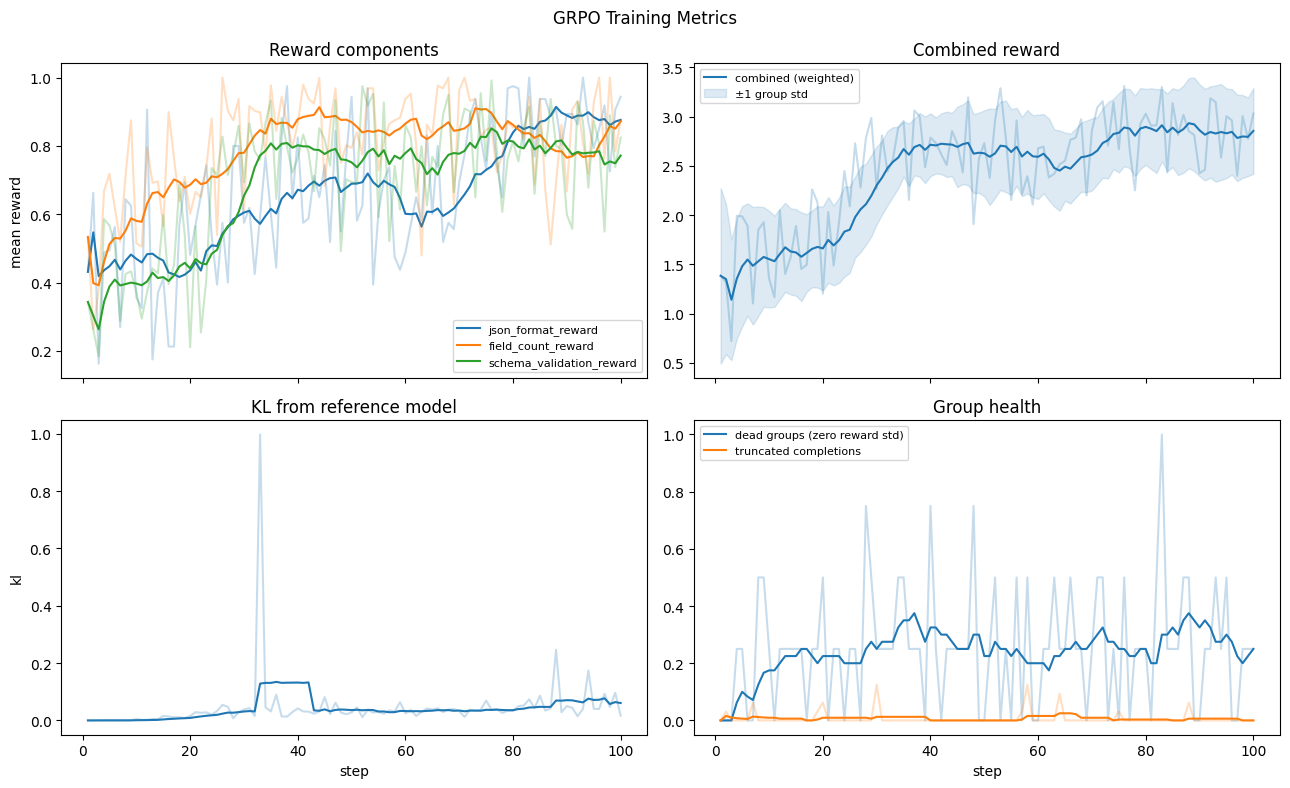

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
logs = logs[logs["reward"].notna()].set_index("step")
ROLL = 10  # each step covers only 4 prompts; judge trends on a rolling mean


def raw_and_rolling(ax, series, label=None):
    """Plot the noisy per-step values faintly and their rolling mean on top."""
    (faint,) = ax.plot(series.index, series, alpha=0.25)
    ax.plot(series.index, series.rolling(ROLL, min_periods=1).mean(),
            color=faint.get_color(), label=label)
    return faint.get_color()


fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

# Reward components — watch json_format for the first move off the wrong-form value
ax = axes[0, 0]
for col in logs.columns:
    if col.startswith("rewards/") and col.endswith("/mean"):
        raw_and_rolling(ax, logs[col], label=col.removeprefix("rewards/").removesuffix("/mean"))
ax.set_title("Reward components")
ax.set_ylabel("mean reward")
ax.legend(fontsize=8)

# Combined reward with its within-group spread — the spread is the learning signal
ax = axes[0, 1]
color = raw_and_rolling(ax, logs["reward"], label="combined (weighted)")
if "reward_std" in logs:
    rolling_mean = logs["reward"].rolling(ROLL, min_periods=1).mean()
    rolling_std = logs["reward_std"].rolling(ROLL, min_periods=1).mean()
    ax.fill_between(logs.index, rolling_mean - rolling_std, rolling_mean + rolling_std,
                    alpha=0.15, color=color, label="±1 group std")
ax.set_title("Combined reward")
ax.legend(fontsize=8)

# KL from the reference model — should lift off zero after warmup
ax = axes[1, 0]
if "kl" in logs:
    raw_and_rolling(ax, logs["kl"])
ax.set_title("KL from reference model")
ax.set_ylabel("kl")
ax.set_xlabel("step")

# Group health — dead groups and truncated completions
ax = axes[1, 1]
if "frac_reward_zero_std" in logs:
    raw_and_rolling(ax, logs["frac_reward_zero_std"], label="dead groups (zero reward std)")
if "completions/clipped_ratio" in logs:
    raw_and_rolling(ax, logs["completions/clipped_ratio"], label="truncated completions")
ax.set_title("Group health")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("step")
ax.legend(fontsize=8)

fig.suptitle("GRPO Training Metrics")
fig.tight_layout()
plt.show()


## Merge the LoRA Adapter into the Base Model and Save

Finally, merge the LoRA adapter back into the base model and save.

In [19]:
MERGED_DIR = f"{training_args.output_dir}-merged"

# Optional: save just the LoRA adapter if you want to keep the standalone deltas
# trainer.save_model(training_args.output_dir)

merged_model = trainer.model.merge_and_unload()
merged_model.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)
print(f"merged model saved to {MERGED_DIR}")

# Optional: push the merged model to the Hugging Face Hub. Requires an authenticated
# session (huggingface_hub.login(token=HF_TOKEN) or `huggingface-cli login`).
# HUB_REPO = "your-username/lfm25-350m-nemotron-schema-grpo-merged"
# merged_model.push_to_hub(HUB_REPO)
# tokenizer.push_to_hub(HUB_REPO)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

merged model saved to ./outputs/lfm25-350m-nemotron-schema-grpo-merged
